# 

In [2]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import random
import numpy as np
import cv2
import seaborn as sns
from skimage.feature import hog

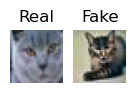

In [3]:
real_images = os.listdir("./CIFAKE/train/REAL")
ai_images = os.listdir("./CIFAKE/train/FAKE")

fig, axes = plt.subplots(1, 2, figsize=(1.5, 2))
# for i in range(1):
ind = 11533
img_real = Image.open(f"./CIFAKE/train/REAL/{real_images[ind]}")
img_ai = Image.open(f"./CIFAKE/train/FAKE/{ai_images[ind]}")

axes[0].imshow(img_real)
axes[0].set_title("Real")
axes[0].axis("off")

axes[1].imshow(img_ai)
axes[1].set_title("Fake")
axes[1].axis("off")

plt.show()

In [4]:
def get_image_stats(image_path):
    img = Image.open(image_path)
    return img.size, np.array(img).shape  # (width, height), (H, W, C)

print(get_image_stats(f"./CIFAKE/train/REAL/{real_images[0]}"))
print(get_image_stats(f"./CIFAKE/train/FAKE/{ai_images[0]}"))

((32, 32), (32, 32, 3))
((32, 32), (32, 32, 3))


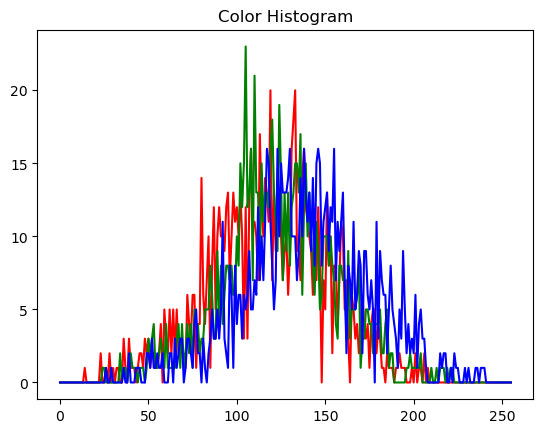

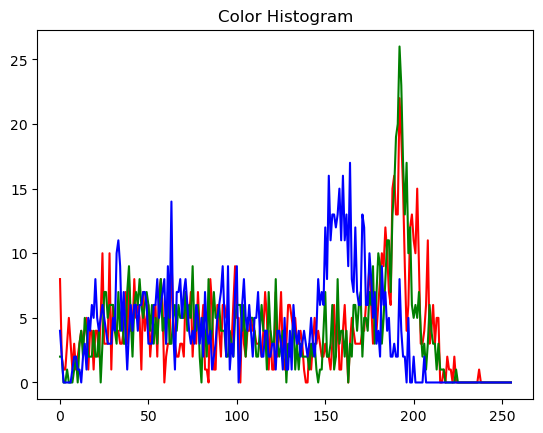

In [5]:
def plot_color_histogram(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    colors = ('r', 'g', 'b')
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        sns.lineplot(x=range(256), y=hist.ravel(), color=color)

    plt.title("Color Histogram")
    plt.show()

plot_color_histogram(f"./CIFAKE/train/REAL/{real_images[11533]}")
plot_color_histogram(f"./CIFAKE/train/FAKE/{ai_images[11533]}")

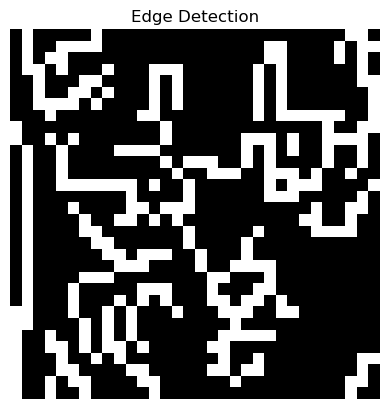

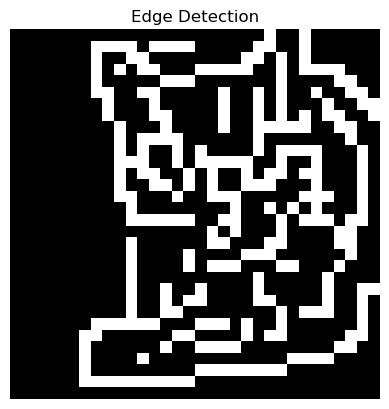

In [6]:
def edge_detection(image_path):
    img = cv2.imread(image_path, 0)  # Load in grayscale
    edges = cv2.Canny(img, 100, 200)
    
    plt.imshow(edges, cmap="gray")
    plt.title("Edge Detection")
    plt.axis("off")
    plt.show()

edge_detection(f"./CIFAKE/train/Real/{real_images[11533]}")
edge_detection(f"./CIFAKE/train/FAKE/{ai_images[11533]}")


In [7]:
print(real_images[11533])

1153 (4).jpg


In [8]:
def compute_stats(image_path):
    img = cv2.imread(image_path, 0)
    mean, std = np.mean(img), np.std(img)
    return mean, std

print("Real Image Stats:", compute_stats(f"./CIFAKE/train/REAL/{real_images[11533]}"))
print("AI Image Stats:", compute_stats(f"./CIFAKE/train/FAKE/{ai_images[11533]}"))

Real Image Stats: (np.float64(123.56640625), np.float64(33.28430860908727))
AI Image Stats: (np.float64(120.5166015625), np.float64(62.88276323356125))


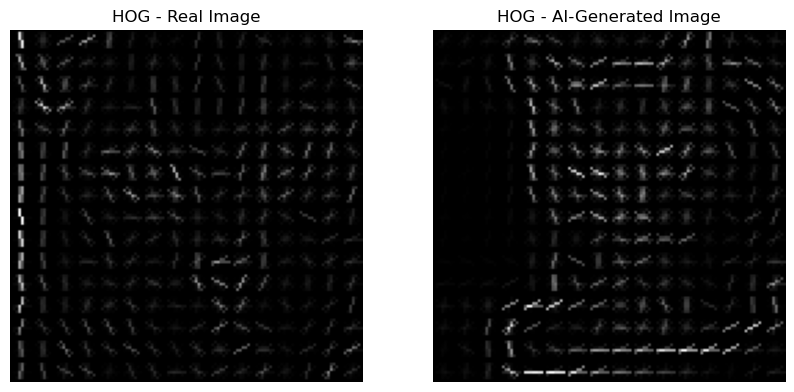

In [9]:
def extract_hog_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
    img = cv2.resize(img, (128, 128))  # Resize for consistency
    
    features, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True)
    
    return features, hog_image

# Test on sample images
real_hog_features, real_hog_image = extract_hog_features(f"./CIFAKE/train/REAL/{real_images[11533]}")
ai_hog_features, ai_hog_image = extract_hog_features(f"./CIFAKE/train/FAKE/{ai_images[11533]}")

# Plot HOG features
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(real_hog_image, cmap="gray")
ax[0].set_title("HOG - Real Image")
ax[0].axis("off")

ax[1].imshow(ai_hog_image, cmap="gray")
ax[1].set_title("HOG - AI-Generated Image")
ax[1].axis("off")

plt.show()

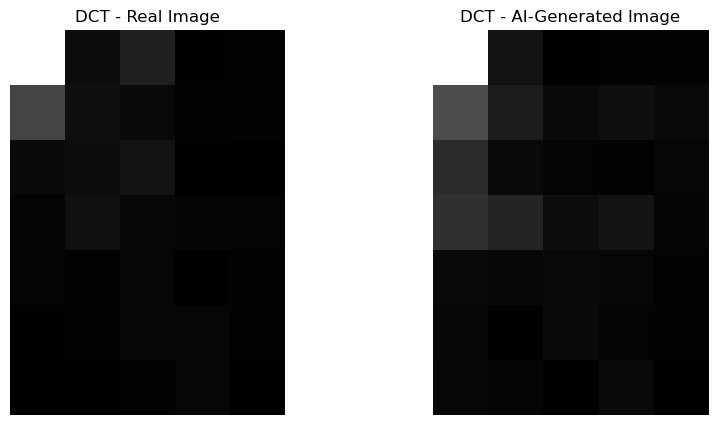

In [10]:
def extract_dct_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))  # Resize for consistency
    
    dct = cv2.dct(np.float32(img))  # Apply DCT
    dct_abs = np.abs(dct)  # Get absolute values
    
    return dct_abs[:7, :5]  # Return top-left 20x20 DCT coefficients (low-frequency components)

# Test on sample images
real_dct = extract_dct_features(f"./CIFAKE/train/REAL/{real_images[1050]}")
ai_dct = extract_dct_features(f"./CIFAKE/train/FAKE/{ai_images[1050]}")

# Plot DCT coefficients
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(real_dct, cmap="gray")
ax[0].set_title("DCT - Real Image")
ax[0].axis("off")

ax[1].imshow(ai_dct, cmap="gray")
ax[1].set_title("DCT - AI-Generated Image")
ax[1].axis("off")

plt.show()